# Лабораторная работа No8

Распараллеливание циклов в CUDA: программа «Число π».

Напишите CUDA-программу,  которая вычисляет число π с точностью
до N знаков после запятой. Используйте следующую формулу:

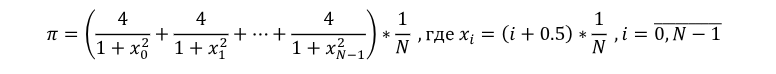

Входные данные: одно целое число N (точность вычисления).

Выходные данные: одно вещественное число pi.

In [1]:
%%writefile pi.cu
#include <iostream>
#include <cuda_runtime.h>

__global__ void calcPiKernel(double* gdata, int n)
{
    extern __shared__ double sdata[];

    int threadId = blockIdx.x * blockDim.x + threadIdx.x;
    int tid = threadIdx.x;

    // Каждая нить считает свою часть суммы
    double localSum = 0.0;
    const double coef = 1.0 / n;

    for (int i = threadId; i < n; i += blockDim.x * gridDim.x)
    {
        double xi = (i + 0.5) * coef;
        localSum += 4.0 / (1.0 + xi * xi);
    }

    // Сохраняем результат нити в shared memory
    sdata[tid] = localSum;
    __syncthreads();

    // Редукция внутри блока методом Interleaved addressing
    for (int i = 1; i < blockDim.x; i *= 2)
    {
        int index = 2 * i * tid;
        if (index < blockDim.x)
        {
            sdata[index] += sdata[index + i];
        }
        __syncthreads();
    }

    // Нить 0 каждого блока записывает результат блока в глобальную память
    if (tid == 0)
    {
        gdata[blockIdx.x] = sdata[0];
    }
}

int main()
{
    int n;
    std::cin >> n;

    int blockSize = 256;
    int gridSize = (n - 1) / blockSize + 1;
    if (gridSize > 1024) gridSize = 1024;

    // Выделение памяти на GPU для частичных сумм блоков
    double* dData;
    cudaMalloc((void**)&dData, gridSize * sizeof(double));

    // Запуск ядра (3й параметр - размер shared memory)
    calcPiKernel<<<gridSize, blockSize, blockSize * sizeof(double)>>>(dData, n);

    // Копируем частичные суммы блоков на CPU
    double* hData = new double[gridSize];
    cudaMemcpy(hData, dData, gridSize * sizeof(double), cudaMemcpyDeviceToHost);

    // Финальная редукция на CPU
    double pi = 0.0;
    for (int i = 0; i < gridSize; i++)
    {
        pi += hData[i];
    }
    pi /= n;

    std::cout << std::fixed;
    std::cout.precision(8);
    std::cout << pi << std::endl;

    cudaFree(dData);
    delete[] hData;

    return 0;
}

Writing pi.cu


In [2]:
!nvcc pi.cu -o pi && echo "10000000" | ./pi

nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
3.14159265


```
10 000 000 итераций
        |
        !
[Блок 0]  [Блок 1]  ...  [Блок 1023]   < 1024 блока на GPU
256 нитей  256 нитей      256 нитей
    |          |               |
  сумма      сумма           сумма       < shared memory редукция
    |          |               |
    └──────────┴───────────────┘
                   |
                  CPU                   < складывает 1024 числа
                   |
                  π ≈ 3.14159265
```

1. Как будут распределены итерации по нитям?

У нас используется схема stride-based (шаговое) распределение итераций. Каждая нить берёт не одну итерацию, а несколько - через равный шаг.

```
for (int i = threadId; i < n; i += blockDim.x * gridDim.x)
```

Шаг равен blockDim.x * gridDim.x - то есть общему количеству нитей. Для примера с n = 10000000, blockSize = 256, gridSize = 1024 суммарно запускается 262144 нити, и каждая обрабатывает примерно 10000000 / 262144 ≈ 38 итераций.

Наглядно для простого примера с 8 итерациями и 4 нитями:

```
Итерация:  0  1  2  3  4  5  6  7
Нить 0:    ✓           ✓
Нить 1:       ✓           ✓
Нить 2:          ✓           ✓
Нить 3:             ✓           ✓
```

Каждая нить считает свою частичную сумму, затем все результаты складываются через редукцию в shared memory внутри блока, и финальная сумма каждого блока передаётся на CPU для итогового суммирования.